# Depedencies

By collecting data on the projects within the WETO portfolio that use other tools
within the portfolio, we can get a sense for the software projects that are at the "core"
of the capabilities.

This network is divided into two types of connectivity:
1. **Direct connections** are software that are connected within the code, so they may
    communicate directly through API's, share memory, and be distributed as a bundle.
2. **Indirect connections** are software that require the outputs of other tools in order
    to construct their inputs. These are connected through workflows rather than code.

In [1]:
from pathlib import Path
import yaml
import networkx as nx

software_attr_dir = Path("..", "..", "software_attributes")
software_database_dir = software_attr_dir / "database"

model_list_inputs = yaml.safe_load( open(software_attr_dir / "database_list.yaml", "r") )
models = model_list_inputs["active"] + model_list_inputs["partial"]

model_attributes_map = {
    model: yaml.safe_load( open( software_database_dir / f"{model}.yaml", "r") )
    for model in models
}

In [2]:
model_connectivity = {}
for model in models:
    model_attributes = model_attributes_map[model]
    if "dependencies" not in model_attributes:
        continue
    model_connectivity[model] = model_attributes["dependencies"]

network_graph = nx.DiGraph()
for model, connections in model_connectivity.items():
    for c in connections:
        weight = 1 if c[1] == "direct" else 2
        network_graph.add_edge(model, c[0], weight=weight)

In [8]:
import html as html_lib
import json
import warnings
from pyvis.network import Network
from IPython.display import HTML

net = Network(
    height="750px",
    width="100%",
    directed=True,
    cdn_resources="remote",
    bgcolor="#ffffff",
    font_color="#333333",
)

# Nodes sized by how many other tools depend on them
for node in network_graph.nodes:
    in_degree = network_graph.in_degree(node)
    net.add_node(
        node,
        label=node,
        size=10 + 4 * in_degree,
        title=f"{node} — depended on by {in_degree} tool(s)",
    )

# Edges colored/styled by connection type
for source, target, attrs in network_graph.edges(data=True):
    is_direct = attrs["weight"] == 1
    net.add_edge(
        source,
        target,
        color="#1f77b4" if is_direct else "#ff7f0e",
        dashes=not is_direct,
        title="direct" if is_direct else "indirect",
    )

# A large fixed label font with a white halo keeps text legible without zooming,
# while a compact physics layout keeps the fitted view close enough to read.
net.set_options(json.dumps({
    "nodes": {
        "font": {
            "size": 32,
            "face": "arial",
            "color": "#222222",
            "strokeWidth": 4,
            "strokeColor": "#ffffff",
        },
    },
    "edges": {
        "color": {"inherit": True},
        "width": 3,
        "smooth": {"type": "dynamic"},
    },
    "physics": {
        "barnesHut": {
            # Disconnected components only attract via centralGravity; raise it
            # (and soften the repulsion) to pull separate clusters closer.
            "gravitationalConstant": -18000,
            "centralGravity": 1.5,
            "springLength": 95,
            "springConstant": 0.04,
            "damping": 0.09,
            "avoidOverlap": 0.2,
        },
        "minVelocity": 0.75,
        "stabilization": {"iterations": 250},
    },
    "interaction": {
        "hover": True,
        "dragNodes": True,
        "navigationButtons": True,
    },
}))

# Embed the generated page in an iframe so it renders inline and in the built docs
net_html = net.generate_html(notebook=False)
with warnings.catch_warnings():
    # HTML() warns when its content contains an <iframe>; that is exactly what
    # we want here, so the suggestion to use IFrame does not apply.
    warnings.simplefilter("ignore", UserWarning)
    display(
        HTML(
            f'<iframe srcdoc="{html_lib.escape(net_html)}" '
            'width="100%" height="770" frameborder="0"></iframe>'
        )
    )


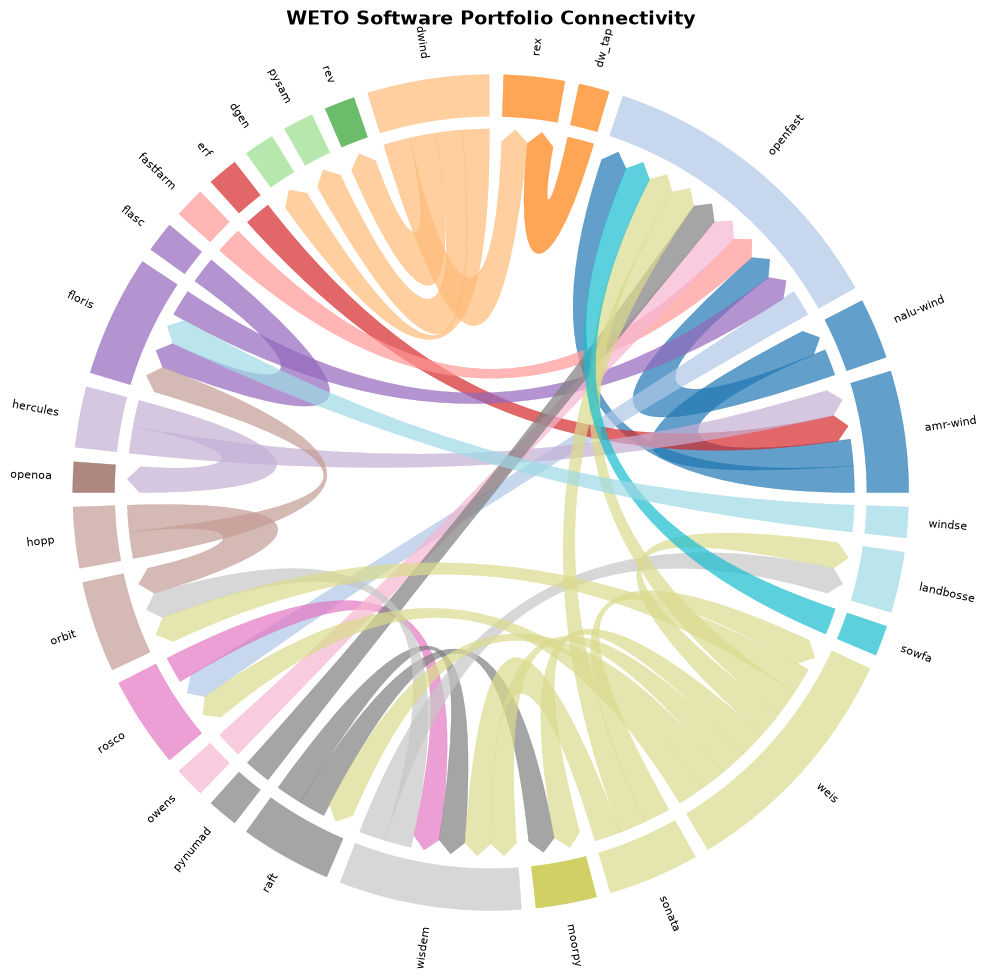

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_chord_diagram import chord_diagram
import networkx as nx

# Restrict to tools that participate in at least one dependency relationship
connected_nodes = [n for n in network_graph.nodes if network_graph.degree(n) > 0]

# Directed adjacency matrix: entry [i, j] encodes a dependency of i on j.
# Use unweighted edges (1 per connection) so ribbon width reflects the number
# of dependencies rather than the direct/indirect weight.
adjacency = nx.to_numpy_array(network_graph, nodelist=connected_nodes, weight=None)

fig, ax = plt.subplots(figsize=(10, 10))
# "Sink" tools (depended upon but depending on nothing) have a zero row sum,
# which triggers a benign divide-by-zero warning inside mpl_chord_diagram.
with np.errstate(invalid="ignore", divide="ignore"):
    chord_diagram(
        adjacency,
        names=connected_nodes,
        directed=True,
        rotate_names=True,
        fontsize=8,
        cmap="tab20",
        ax=ax,
    )
ax.set_title("WETO Software Portfolio Connectivity", fontsize=14, fontweight="bold")
plt.show()


(np.float64(0.0), np.float64(100.0), np.float64(0.0), np.float64(100.0))

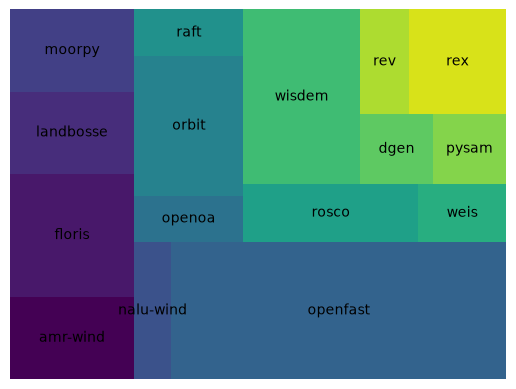

In [5]:
import squarify
import matplotlib.pyplot as plt

# Count the number of projects depending on each project
depending = {model: 0 for model in models}
for model, dependents in model_connectivity.items():
    for d in dependents:
        depending[d[0]] = depending[d[0]] + 1

non_zero = {k:v for k,v in depending.items() if v > 0}

cmap = plt.get_cmap("viridis")
colors = [cmap(i / len(non_zero)) for i in range(len(non_zero))]

squarify.plot(list(non_zero.values()), label=list(non_zero.keys()), color=colors)
plt.axis("off")